Log Marginal Likelihood (initial): -17.598
Log Marginal Likelihood (optimized): -3.875
Accuracy: 1.000 (initial) 1.000 (optimized)
Log-loss: 0.214 (initial) 0.319 (optimized)


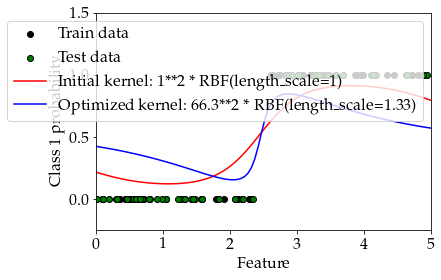

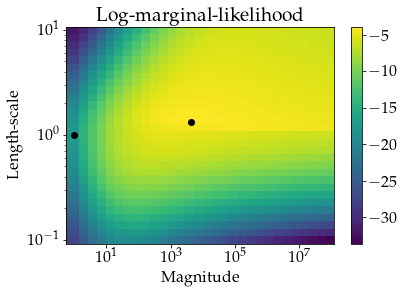

In [22]:
# Authors: Jan Hendrik Metzen <jhm@informatik.uni-bremen.de>
#
# License: BSD 3 clause

import numpy as np

from matplotlib import pyplot as plt

from sklearn.metrics import accuracy_score, log_loss
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF


# Generate data
train_size = 50
rng = np.random.RandomState(0)
X = rng.uniform(0, 5, 100)[:, np.newaxis]
y = np.array(X[:, 0] > 2.5, dtype=int)

# Specify Gaussian Processes with fixed and optimized hyperparameters
gp_fix = GaussianProcessClassifier(kernel=1.0 * RBF(length_scale=1.0), optimizer=None)
gp_fix.fit(X[:train_size], y[:train_size])

gp_opt = GaussianProcessClassifier(kernel=1.0 * RBF(length_scale=1.0))
gp_opt.fit(X[:train_size], y[:train_size])

print(
    "Log Marginal Likelihood (initial): %.3f"
    % gp_fix.log_marginal_likelihood(gp_fix.kernel_.theta)
)
print(
    "Log Marginal Likelihood (optimized): %.3f"
    % gp_opt.log_marginal_likelihood(gp_opt.kernel_.theta)
)

print(
    "Accuracy: %.3f (initial) %.3f (optimized)"
    % (
        accuracy_score(y[:train_size], gp_fix.predict(X[:train_size])),
        accuracy_score(y[:train_size], gp_opt.predict(X[:train_size])),
    )
)
print(
    "Log-loss: %.3f (initial) %.3f (optimized)"
    % (
        log_loss(y[:train_size], gp_fix.predict_proba(X[:train_size])[:, 1]),
        log_loss(y[:train_size], gp_opt.predict_proba(X[:train_size])[:, 1]),
    )
)


# Plot posteriors
plt.figure()
plt.scatter(
    X[:train_size, 0], y[:train_size], c="k", label="Train data", edgecolors=(0, 0, 0)
)
plt.scatter(
    X[train_size:, 0], y[train_size:], c="g", label="Test data", edgecolors=(0, 0, 0)
)
X_ = np.linspace(0, 5, 100)
plt.plot(
    X_,
    gp_fix.predict_proba(X_[:, np.newaxis])[:, 1],
    "r",
    label="Initial kernel: %s" % gp_fix.kernel_,
)
plt.plot(
    X_,
    gp_opt.predict_proba(X_[:, np.newaxis])[:, 1],
    "b",
    label="Optimized kernel: %s" % gp_opt.kernel_,
)
plt.xlabel("Feature")
plt.ylabel("Class 1 probability")
plt.xlim(0, 5)
plt.ylim(-0.25, 1.5)
plt.legend(loc="best")

# Plot LML landscape
plt.figure()
theta0 = np.logspace(0, 8, 30)
theta1 = np.logspace(-1, 1, 29)
Theta0, Theta1 = np.meshgrid(theta0, theta1)
LML = [
    [
        gp_opt.log_marginal_likelihood(np.log([Theta0[i, j], Theta1[i, j]]))
        for i in range(Theta0.shape[0])
    ]
    for j in range(Theta0.shape[1])
]
LML = np.array(LML).T
plt.plot(
    np.exp(gp_fix.kernel_.theta)[0], np.exp(gp_fix.kernel_.theta)[1], "ko", zorder=10
)
plt.plot(
    np.exp(gp_opt.kernel_.theta)[0], np.exp(gp_opt.kernel_.theta)[1], "ko", zorder=10
)
plt.pcolor(Theta0, Theta1, LML)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.xlabel("Magnitude")
plt.ylabel("Length-scale")
plt.title("Log-marginal-likelihood")

plt.show()

(61600, 3)
(61600, 3)


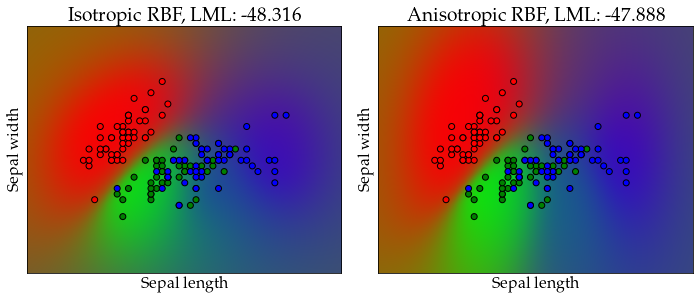

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

# import some data to play with
iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features.
y = np.array(iris.target, dtype=int)

h = 0.02  # step size in the mesh

kernel = 1.0 * RBF([1.0])
gpc_rbf_isotropic = GaussianProcessClassifier(kernel=kernel).fit(X, y)
kernel = 1.0 * RBF([1.0, 1.0])
gpc_rbf_anisotropic = GaussianProcessClassifier(kernel=kernel).fit(X, y)

# create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

titles = ["Isotropic RBF", "Anisotropic RBF"]
plt.figure(figsize=(10, 5))
for i, clf in enumerate((gpc_rbf_isotropic, gpc_rbf_anisotropic)):
    # Plot the predicted probabilities. For that, we will assign a color to
    # each point in the mesh [x_min, m_max]x[y_min, y_max].
    plt.subplot(1, 2, i + 1)

    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    print(Z.shape)

    # Put the result into a color plot
    Z = Z.reshape((xx.shape[0], xx.shape[1], 3))
    plt.imshow(Z, extent=(x_min, x_max, y_min, y_max), origin="lower")

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=np.array(["r", "g", "b"])[y], edgecolors=(0, 0, 0))
    plt.xlabel("Sepal length")
    plt.ylabel("Sepal width")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(
        "%s, LML: %.3f" % (titles[i], clf.log_marginal_likelihood(clf.kernel_.theta))
    )

plt.tight_layout()
plt.show()

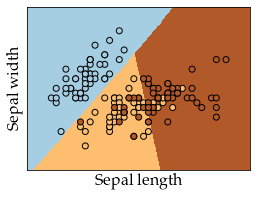

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn import datasets

# import some data to play with
iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features.
Y = iris.target

# Create an instance of Logistic Regression Classifier and fit the data.
logreg = LogisticRegression(C=1e5)
logreg.fit(X, Y)

# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1, figsize=(4, 3))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors="k", cmap=plt.cm.Paired)
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())

plt.show()


In [1]:
import numpy as np
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

%matplotlib inline

refs = ['Chutjian1981','Buckman1983','Filipovic2000a','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981']
Nrefs = len(refs)
crs_exps, idx = [], 0
for ref in refs:
    print(ref)
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    crs_exps.append( crs.crsData(filename) )
#     print(swarms[idx].ref)
#     print(swarms[idx].variables,swarms[idx].error_provided)
#     for dataType, dataset in swarms[idx].datasets.items():
#         print(crs.typeDictI2S[dataType])
# #         print(dataset.variables)
#         print(dataset.error_provided)
    idx += 1


Chutjian1981
Buckman1983
Filipovic2000a
Filipovic2000b
Khakoo2004
Tsurubuchi1996
Schappe1994
Li1988
Rapp1965
Straub1995
Wetzel1987
Mielewska2004
Panajotovic1997
Gibson1996
Srivastava1981


In [2]:
import crossSections as cross

# datasets
LXCat_refs = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","SIGLO","TRINITI"]
Nsets = len(LXCat_refs)

LXCats = []
for k, ref in enumerate(LXCat_refs[:-2]):
    filename = "./crs/%s.txt" % ref
    LXCats += [cross.multipleCrossSections(filename)]

(80,) (325,)


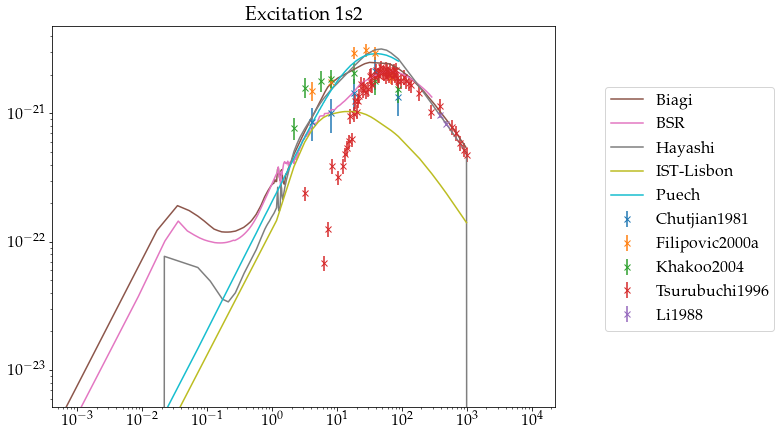

[0 0 0 0 0 1 1 1 1 1 1 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
[-48.10246238785616, -47.53100377824273, -47.90270048350984, -48.17761562048611, -48.463886176135205, -49.22053343780851]


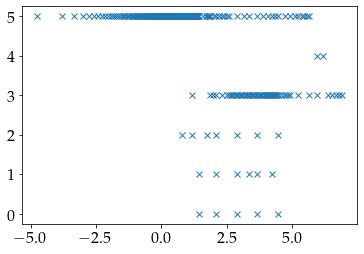

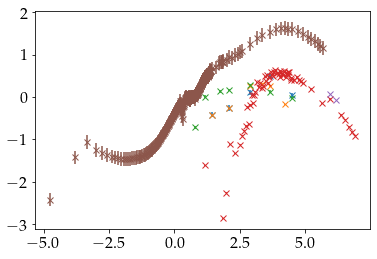

In [52]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

# targets = ['Elastic, momentum','Ionization, total','Excitation, level 1','Excitation, level 2','Excitation, level 3','Excitation, level 4']

dataType = crs.typeDictS2I["Excitation, level 4"]
from models import E_ext

idx = 0

W = []

plt.figure(1)
for k, crs_exp in enumerate(crs_exps):
    if dataType in crs_exp.datasets:
        if(crs_exp.datasets[dataType].error_provided):
            plt.errorbar(crs_exp.datasets[dataType].data[:,0]-E_ext[3],
                         crs_exp.datasets[dataType].data[:,1],
                         yerr=crs_exp.datasets[dataType].data[:,2],
                         label=refs[k],
                         fmt='x')
        else:
            plt.plot(crs_exp.datasets[dataType].data[:,0]-E_ext[3],
                     crs_exp.datasets[dataType].data[:,1], 'x', label=refs[k])
            
        W += [np.copy(crs_exp.datasets[dataType].data)]
            
        if (idx==0):
            X = np.copy(crs_exp.datasets[dataType].data[:,0])
            y = [idx]*crs_exp.datasets[dataType].data.shape[0]
        else:
            X = np.append(X,crs_exp.datasets[dataType].data[:,0],axis=0)
            y += [idx]*crs_exp.datasets[dataType].data.shape[0]
        idx +=1
            
for k, tmp in enumerate(LXCats):
    for c in tmp.crs:
        if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
            plt.loglog(c.data[:,0]-E_ext[3],c.data[:,1],'-',label=LXCat_refs[k])
            
            if (k==1):
                temp = np.copy(c.data[1:,:])
                error = temp[:,1][...,None] * 0.5
                temp = np.append( temp, error, axis=1)
                W += [temp]
                print(X.shape, temp[:,0].shape)
                X = np.append(X,temp[:,0],axis=0)
                y += [idx]*temp.shape[0]
                idx += 1
                
plt.xscale('log')
plt.yscale('log')
plt.title('Excitation 1s2')
plt.legend(loc=(1.1,0.2))
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# E1 = 11.55
# plt.figure(1)
# plt.errorbar(W[:,0]-E1,W[:,1],yerr=W[:,2],fmt='.')

X -= E_ext[3]
X = np.log(X)
X = X[:,np.newaxis]
y = np.array(y,dtype=int)
print(y)

plt.figure(2)
plt.plot(X,y,'x')

plt.figure(3)
wm = []
for ws in W:
    ws[:,0] -= E_ext[3]
    ws[:,0] = np.log(ws[:,0])
    ws[:,2] = np.log(1.0 + ws[:,2] / ws[:,1]) ** 2
    ws[:,1] = np.log(ws[:,1])
    wsm = np.mean(ws[:,1])
    ws[:,1] -= wsm
    wm += [wsm]
    plt.errorbar(ws[:,0],ws[:,1],yerr=ws[:,2],fmt='x')
# plt.xscale('log')
# plt.yscale('log')
print(wm)

(405, 1) (405,)
(100, 6)


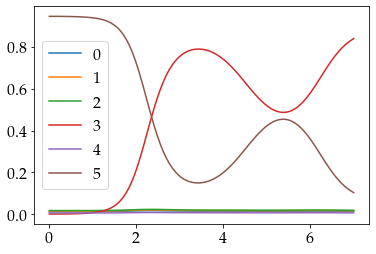

In [54]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

print(X.shape, y.shape)
kernel = 1.0 * RBF([1.0])
gpc_rbf = GaussianProcessClassifier(kernel=kernel).fit(X, y)

xtest = np.linspace(0.,7.,100)[:,np.newaxis]

Z = gpc_rbf.predict_proba(xtest)
print(Z.shape)
plt.figure(1)
for k in range(6):
    plt.plot(xtest,Z[:,k],'-',label=str(k))
plt.legend()

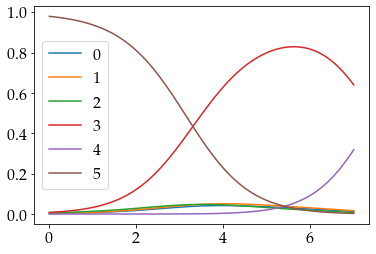

In [70]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(C=1e55).fit(X, y)
Z = clf.predict_proba(xtest)

plt.figure(1)
for k in range(6):
    plt.plot(xtest,Z[:,k],'-',label=str(k))
plt.legend()

Optimization restart 1/3, f = 1.1375859648387507
Optimization restart 2/3, f = 1.1375859648343996
Optimization restart 3/3, f = 1.1375859649484985
Optimization restart 1/3, f = -0.3324142552794225
Optimization restart 2/3, f = -0.33241425530649193
Optimization restart 3/3, f = -0.3324142553101157
Optimization restart 1/3, f = 1.5735882495746694
Optimization restart 2/3, f = 1.5735882496025435
Optimization restart 3/3, f = 1.573588249612071
Optimization restart 1/3, f = -7.430121822720281
Optimization restart 2/3, f = -7.430121822720022
Optimization restart 3/3, f = -7.430121822718242
Optimization restart 1/3, f = -2.3774668795938965
Optimization restart 2/3, f = -2.3774668271047426
Optimization restart 3/3, f = -1.7259494923582595
Optimization restart 1/3, f = 29.054506200839228
Optimization restart 2/3, f = 29.05450620082391
Optimization restart 3/3, f = 29.05450620082268


(1e-23, 1e-20)

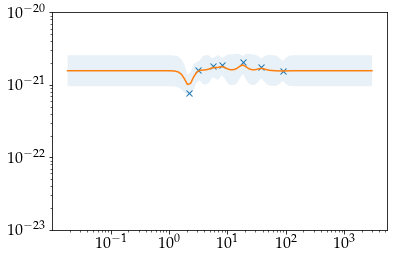

In [73]:
import GPy
k2 = GPy.kern.RBF(1)
k3 = GPy.kern.Matern32(1)
k4 = GPy.kern.Matern52(1)
kernel = k3
kernel.randomize()

exp_models = []
for ws in W:
    m = GPy.models.GPHeteroscedasticRegression(
        (ws[:,0])[:,None],
        (ws[:,1])[:,None],
        GPy.kern.Matern52(1)
    )
    m['.*het_Gauss.variance'] = (ws[:,2])[:,None] #Set the noise parameters to the error in Y
    m.het_Gauss.variance.fix() #We can fix the noise term, since we already know it
    
    m.optimize_restarts(num_restarts = 3)
    exp_models += [m]
    
# plt.figure(1)
# for exp_model in exp_models:
#     exp_model.plot_f()

color = ['k','r','b','g','y']
plt.figure(1)
xtest = np.linspace(-4,8,100)[:,None]
# for k, exp_model in enumerate(exp_models):
k, exp_model = -4, exp_models[-4]
ym, yvar = exp_model.predict(xtest,include_likelihood=False)
ym = np.squeeze(ym)
yvar = np.squeeze(yvar)


plt.plot(np.exp(W[k][:,0]),np.exp(W[k][:,1] + wm[k]),'x')
plt.plot(np.exp(xtest),np.exp(ym + wm[k]),'-')
plt.fill_between(
    np.exp(np.squeeze(xtest)),
    # plus/minus standard deviation (70 percent confidence interval)
    np.exp(ym + wm[k] - 2*np.sqrt(yvar)),
    np.exp(ym + wm[k] + 2*np.sqrt(yvar)),
    alpha=0.1,
    label="Standard deviation",
)
plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-23, 1e-20])